# 数据集概览

本已执行 Notebook 使用可公开的汇总统计和完全合成的期权记录展示论文的四张
数据表，不会在此加载受许可保护的 OptionMetrics 真实记录。

In [1]:
from pathlib import Path
import json
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display


def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "docs" / "data" / "dataset_profile.json").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


ROOT = find_repository_root()
LANGUAGE = os.environ.get("DATASET_NOTEBOOK_LANGUAGE", "en")
if LANGUAGE not in {"en", "zh"}:
    raise ValueError("DATASET_NOTEBOOK_LANGUAGE must be 'en' or 'zh'")

LABELS = {
    "en": {
        "table": "Table",
        "rows": "Rows",
        "period": "Observation period",
        "size": "Size (MiB)",
        "columns": "Columns",
        "missing": "Overall missing cells (%)",
        "date": "Date",
        "symbol": "Symbol",
        "type": "Type",
        "strike": "Strike",
        "iv": "Synthetic IV",
        "chart_title": "Synthetic volatility smile",
        "x_axis": "Strike",
        "y_axis": "Implied volatility",
        "notice": "All displayed option contracts are synthetic.",
    },
    "zh": {
        "table": "数据表",
        "rows": "行数",
        "period": "观测区间",
        "size": "大小（MiB）",
        "columns": "列数",
        "missing": "总体缺失单元格（%）",
        "date": "日期",
        "symbol": "合约代码",
        "type": "类型",
        "strike": "执行价",
        "iv": "合成隐含波动率",
        "chart_title": "合成波动率微笑",
        "x_axis": "执行价",
        "y_axis": "隐含波动率",
        "notice": "所有展示的期权合约均为合成记录。",
    },
}
labels = LABELS[LANGUAGE]
if LANGUAGE == "zh":
    cjk_font_path = Path(sys.prefix) / "fonts" / "NotoSansCJKsc-VF.ttf"
    if not cjk_font_path.is_file():
        raise RuntimeError(
            "Chinese notebook requires the font-ttf-noto-cjk Conda package"
        )
    font_manager.fontManager.addfont(cjk_font_path)
    cjk_font_name = font_manager.FontProperties(fname=cjk_font_path).get_name()
    plt.rcParams["font.family"] = cjk_font_name
    plt.rcParams["axes.unicode_minus"] = False
profile = json.loads(
    (ROOT / "docs" / "data" / "dataset_profile.json").read_text(encoding="utf-8")
)
dictionary_path = ROOT / "docs" / "data" / (
    "data_dictionary_en.csv" if LANGUAGE == "en" else "data_dictionary_zh.csv"
)
synthetic_path = ROOT / "examples" / "synthetic_option_data.csv"

## 覆盖范围与规模

下表仅根据不含单条观测的汇总概况生成。

In [2]:
coverage_rows = []
for name, table in profile["tables"].items():
    coverage_rows.append({
        labels["table"]: name,
        labels["rows"]: table["row_count"],
        labels["period"]: (
            f'{table["date_range"]["min"]} – {table["date_range"]["max"]}'
        ),
        labels["size"]: round(table["file_size_bytes"] / (1024 ** 2), 2),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage.style.format({labels["rows"]: "{:,.0f}", labels["size"]: "{:,.2f}"}))

,数据表,行数,观测区间,大小（MiB）
0,Index Dividend Yield.csv,"7,463",1996-01-04 – 2025-08-29,0.40
1,Zero Coupon Yield Curve.csv,"304,301",1996-01-02 – 2025-08-29,7.08
2,option price.csv,"48,335,273",1996-01-04 – 2025-08-29,"9,410.46"
3,security price.csv,"7,465",1996-01-02 – 2025-08-29,0.69


## 数据质量

缺失率根据汇总概况中的逐列缺失数量计算，不需要读取任何原始记录。

In [3]:
quality_rows = []
for name, table in profile["tables"].items():
    total_cells = table["row_count"] * len(table["columns"])
    missing_cells = sum(table["missing_counts"].values())
    quality_rows.append({
        labels["table"]: name,
        labels["columns"]: len(table["columns"]),
        labels["missing"]: 100 * missing_cells / total_cells if total_cells else 0,
    })
quality = pd.DataFrame(quality_rows)
display(quality.style.format({labels["missing"]: "{:.3f}"}))

,数据表,列数,总体缺失单元格（%）
0,Index Dividend Yield.csv,11,18.182
1,Zero Coupon Yield Curve.csv,3,0.000
2,option price.csv,38,19.047
3,security price.csv,19,10.526


## 数据字典

以下条目说明主要源字段及其在论文中的用途。

In [4]:
dictionary = pd.read_csv(dictionary_path)
display(dictionary.head(12))

,table,field,description,type_or_unit,dissertation_use
0,Index Dividend Yield.csv,secid,OptionMetrics证券标识符,整数标识符,连接指数层面的数据表
1,Index Dividend Yield.csv,date,观测日期,YYYY-MM-DD,按交易日匹配股息率
2,Index Dividend Yield.csv,cusip,CUSIP证券标识符,文本标识符,核对标的身份
3,Index Dividend Yield.csv,ticker,标的代码,文本标识符,筛选SPX样本
4,Index Dividend Yield.csv,sic,标准行业分类代码,整数代码,说明证券元数据
5,Index Dividend Yield.csv,index_flag,证券是否为指数的标志,二元标志,验证SPX标的
6,Index Dividend Yield.csv,exchange_d,供应商交易所代码,整数代码,说明上市信息
7,Index Dividend Yield.csv,class,证券类别,类别或空值,说明证券元数据
8,Index Dividend Yield.csv,issue_type,供应商证券类型代码,类别,验证标的类型
9,Index Dividend Yield.csv,industry_group,供应商行业组代码,类别或空值,说明证券元数据


## 合成期权示例

以下所有合约均为人工构造，并标记为 `synthetic_only`。

In [5]:
synthetic = pd.read_csv(synthetic_path)
if not synthetic["symbol_flag"].eq("synthetic_only").all():
    raise ValueError("Synthetic example contains an unmarked row")
synthetic_view = pd.DataFrame({
    labels["date"]: synthetic["date"],
    labels["symbol"]: synthetic["symbol"],
    labels["type"]: synthetic["cp_flag"],
    labels["strike"]: synthetic["strike_price"] / 1000,
    labels["iv"]: synthetic["impl_volatility"],
})
print(labels["notice"])
display(synthetic_view.style.format({
    labels["strike"]: "{:,.0f}",
    labels["iv"]: "{:.1%}",
}))

所有展示的期权合约均为合成记录。


,日期,合约代码,类型,执行价,合成隐含波动率
0,2030-01-02,SYN_C_4000,C,"4,000",24.0%
1,2030-01-02,SYN_C_4200,C,"4,200",21.0%
2,2030-01-02,SYN_C_4400,C,"4,400",19.0%
3,2030-01-02,SYN_P_4600,P,"4,600",19.0%
4,2030-01-02,SYN_P_4800,P,"4,800",21.0%
5,2030-01-02,SYN_P_5000,P,"5,000",24.0%


## 波动率微笑示意

该图只使用合成示例生成，不属于论文的实证结果。

findfont: Failed to find font weight normal, now using 100.


findfont: Failed to find font weight normal, now using 100.


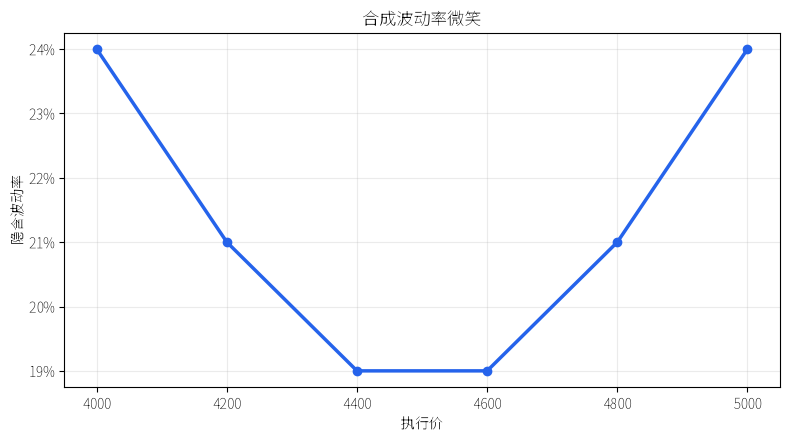

In [6]:
smile = synthetic.assign(strike=synthetic["strike_price"] / 1000).sort_values("strike")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    smile["strike"],
    smile["impl_volatility"],
    color="#2563eb",
    marker="o",
    linewidth=2.5,
)
ax.set_title(labels["chart_title"])
ax.set_xlabel(labels["x_axis"])
ax.set_ylabel(labels["y_axis"])
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()